# ⛽ Fuel Station Operations — Analytics

**Problem:** Detect revenue leakage from fuel under-dispensing and identify drivers of low customer retention.

| Hypothesis | Statement |
|---|---|
| H1 — Fraud | Fraud-prone stations under-dispense fuel → revenue leakage + lower repeat visits |
| H2 — Wait Time | Higher wait time during peak hours → lower repeat rate |
| H3 — Trust | Customers at fraud stations are less likely to return |

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False,
                     'axes.titleweight':'bold','axes.titlesize':12})
C = ['#2563EB','#DC2626','#16A34A','#D97706']

## 2. Data Simulation

In [2]:
# ── Customers ──────────────────────────────────────────────────────────────
customers = pd.DataFrame({
    'customer_id'  : range(1, 5001),
    'customer_type': np.random.choice(['frequent','occasional'], 5000, p=[0.3,0.7]),
    'signup_date'  : pd.to_datetime('2025-01-01') + pd.to_timedelta(np.random.randint(0,180,5000), unit='D')
})

# ── Stations ───────────────────────────────────────────────────────────────
stations = pd.DataFrame({
    'station_id'      : range(1, 51),
    'city'            : np.random.choice(['Mumbai','Delhi','Bangalore'], 50),
    'num_pumps'       : np.random.randint(4, 12, 50),
    'staff_count'     : np.random.randint(5, 20, 50),
    'quality_score'   : np.round(np.random.uniform(2.5, 5.0, 50), 1),
    'fraud_prone_flag': np.random.choice([0,1], 50, p=[0.8,0.2])
})

# ── Transactions ───────────────────────────────────────────────────────────
N = 100_000
transactions = pd.DataFrame({
    'transaction_id'       : range(1, N+1),
    'customer_id'          : np.random.choice(customers.customer_id, N),
    'station_id'           : np.random.choice(stations.station_id, N),
    'fuel_requested_liters': np.round(np.random.uniform(5, 50, N), 2),
})

# Timestamps — peak-hour weighted
days  = np.random.randint(0, 60, N)
hours = np.random.choice([8,9,10,11,17,18,19,20,12,13,14,15], N, p=[0.10]*8+[0.05]*4)
transactions['txn_timestamp'] = (pd.to_datetime('2025-06-01')
                             + pd.to_timedelta(days, unit='D')
                             + pd.to_timedelta(hours, unit='h')
                             + pd.to_timedelta(np.random.randint(0,60,N), unit='m'))

# Merge station flags
transactions = transactions.merge(
    stations[['station_id','fraud_prone_flag','num_pumps','staff_count']],
    on='station_id', how='left')

# Fuel dispensed — fraud stations under-dispense (95–98%)
fp = transactions.fraud_prone_flag == 1
transactions['fuel_dispensed_liters'] = np.where(
    fp,
    transactions.fuel_requested_liters * np.random.uniform(0.95, 0.98, N),
    transactions.fuel_requested_liters * np.random.uniform(0.99, 1.01, N)
).round(2)

# Wait time — peak hours + capacity/staffing factors
h     = transactions.txn_timestamp.dt.hour
peak  = h.between(8,11) | h.between(17,20)
base  = np.random.uniform(2, 5, N)
pf    = np.where(peak, np.random.uniform(1.5,2.5,N), np.random.uniform(0.8,1.2,N))
transactions['wait_time_minutes'] = np.round(
    base * pf * (1 + (12-transactions.num_pumps)/10 + (20-transactions.staff_count)/20), 2)

# Derived columns
transactions['fuel_diff']   = (transactions.fuel_requested_liters - transactions.fuel_dispensed_liters).round(2)
transactions['fraud_flag']  =  transactions.fuel_diff > 0.2
transactions['amount_paid'] = (transactions.fuel_dispensed_liters * 100).round(2)
transactions['hour']        =  transactions.txn_timestamp.dt.hour
transactions['day']         =  transactions.txn_timestamp.dt.date

# Customer type
transactions = transactions.merge(customers[['customer_id','customer_type']], on='customer_id', how='left')

# Repeat customer — probability model
prob = np.where(transactions.customer_type=='frequent', 0.60, 0.30)
prob = np.where(transactions.wait_time_minutes > 15,   prob * 0.70, prob)
prob = np.where(transactions.fuel_diff > 0.2,          prob * 0.50, prob)
transactions['repeat_customer'] = np.random.rand(N) < np.clip(prob, 0, 1)

transactions.drop(columns=['fraud_prone_flag','num_pumps','staff_count'], inplace=True)
print(f'transactions: {transactions.shape}')
transactions.head()

transactions: (100000, 14)


,transaction_id,customer_id,station_id,fuel_requested_liters,txn_timestamp,fuel_dispensed_liters,wait_time_minutes,fuel_diff,fraud_flag,amount_paid,hour,day,customer_type,repeat_customer
0,1,2583,49,6.05,2025-06-26 20:35:00,6.06,17.09,-0.01,False,606.0,20,2025-06-26,occasional,False
1,2,3838,31,12.60,2025-06-04 20:36:00,12.53,15.80,0.07,False,1253.0,20,2025-06-04,frequent,True
2,3,527,38,26.68,2025-06-19 17:31:00,26.82,18.29,-0.14,False,2682.0,17,2025-06-19,occasional,False
3,4,1666,39,39.02,2025-07-03 18:33:00,38.74,9.03,0.28,True,3874.0,18,2025-07-03,occasional,False
4,5,1139,1,9.16,2025-07-22 08:42:00,9.25,11.13,-0.09,False,925.0,8,2025-07-22,occasional,False


In [3]:
# ── Sensor Data ────────────────────────────────────────────────────────────
sensor_data = transactions[['transaction_id','fuel_requested_liters','fuel_dispensed_liters']].copy()
sensor_data.rename(columns={'fuel_requested_liters':'expected_fuel','fuel_dispensed_liters':'actual_fuel'}, inplace=True)
sensor_data['actual_fuel'] = (sensor_data.actual_fuel * np.random.uniform(0.995,1.005,N)).round(2)

# ── Export ─────────────────────────────────────────────────────────────────

## 3. Export to CSV

In [4]:
import os

export_dir = 'exported_csvs'
os.makedirs(export_dir, exist_ok=True)

# ── transactions: match DDL column order exactly + PostgreSQL booleans ──
ddl_cols = [
    'transaction_id', 'customer_id', 'station_id', 'txn_timestamp',
    'fuel_requested_liters', 'fuel_dispensed_liters', 'wait_time_minutes',
    'amount_paid', 'fuel_diff', 'fraud_flag', 'customer_type',
    'repeat_customer', 'hour', 'day'
]

transactions_pg = transactions.copy()
transactions_pg['fraud_flag']      = transactions_pg['fraud_flag'].map({True: 'true', False: 'false'})
transactions_pg['repeat_customer'] = transactions_pg['repeat_customer'].map({True: 'true', False: 'false'})
transactions_pg = transactions_pg[ddl_cols]

# ── Export all 4 tables ─────────────────────────────────────────────────
transactions_pg.to_csv(f'{export_dir}/transactions.csv', index=False)
customers.to_csv(f'{export_dir}/customers.csv',          index=False)
stations.to_csv(f'{export_dir}/stations.csv',            index=False)
sensor_data.to_csv(f'{export_dir}/sensor_data.csv',      index=False)

print(f'✅ Exported 4 tables to ./{export_dir}/')
print(f'   transactions.csv  — {len(transactions_pg):,} rows | columns: {transactions_pg.columns.tolist()}')
print(f'   customers.csv     — {len(customers):,} rows')
print(f'   stations.csv      — {len(stations):,} rows')
print(f'   sensor_data.csv   — {len(sensor_data):,} rows')

✅ Exported 4 tables to ./exported_csvs/
   transactions.csv  — 100,000 rows | columns: ['transaction_id', 'customer_id', 'station_id', 'txn_timestamp', 'fuel_requested_liters', 'fuel_dispensed_liters', 'wait_time_minutes', 'amount_paid', 'fuel_diff', 'fraud_flag', 'customer_type', 'repeat_customer', 'hour', 'day']
   customers.csv     — 5,000 rows
   stations.csv      — 50 rows
   sensor_data.csv   — 100,000 rows


## 3b. Import CSVs into PostgreSQL

In [5]:
import psycopg2, os

# ── Connection settings — update these ────────────────────────────────────
DB_HOST = 'localhost'
DB_PORT = 5432
DB_NAME = 'fuel_analytics'
DB_USER = 'postgres'
DB_PASS = 'your_password_here'   # <-- change this

export_dir = os.path.abspath('exported_csvs')

tables = [
    ('transactions', os.path.join(export_dir, 'transactions.csv')),
    ('customers',    os.path.join(export_dir, 'customers.csv')),
    ('stations',     os.path.join(export_dir, 'stations.csv')),
    ('sensor_data',  os.path.join(export_dir, 'sensor_data.csv')),
]

conn = psycopg2.connect(host='localhost', port=5432, dbname='fuel_analytics',
                        user='postgres', password='Aditya@18')
conn.autocommit = True
cur = conn.cursor()

for table, csv_path in tables:
    # Forward slashes for psycopg2 on Windows
    csv_path_fwd = csv_path.replace('\\', '/')
    with open(csv_path, 'r', encoding='utf-8') as f:
        cur.copy_expert(f"COPY {table} FROM STDIN CSV HEADER", f)
    print(f'✅ Imported {table}')

cur.close()
conn.close()
print('\n🎉 All 4 tables imported successfully!')

✅ Imported transactions
✅ Imported customers
✅ Imported stations
✅ Imported sensor_data

🎉 All 4 tables imported successfully!


## 4. Analysis

In [6]:
txn = transactions.merge(
    stations[['station_id','fraud_prone_flag','city']], on='station_id', how='left')

### H1 — Fraud: Under-Dispensing & Revenue Leakage

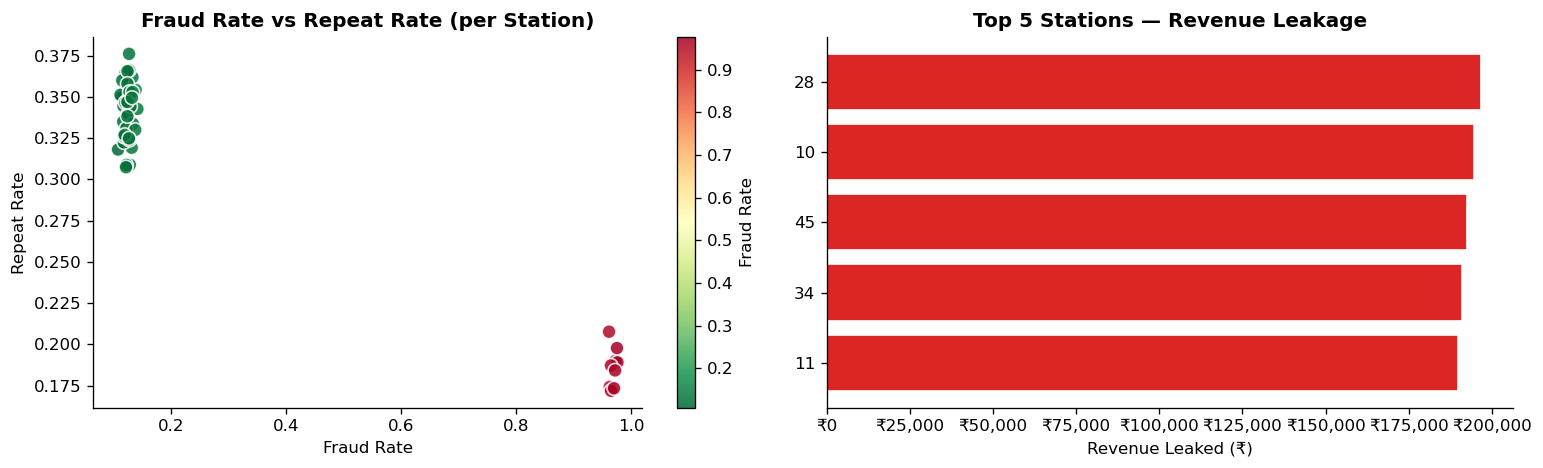

Revenue Collected : ₹273,782,799
Revenue Leaked    : ₹2,284,595  (0.83%)
Correlation (fraud_rate ↔ repeat_rate): -0.965


In [7]:
station_stats = (
    txn.groupby('station_id')
    .agg(fraud_rate=('fraud_flag','mean'), repeat_rate=('repeat_customer','mean'),
         revenue_leaked=('fuel_diff', lambda x: x.clip(lower=0).sum() * 100))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13,4))

sc = axes[0].scatter(station_stats.fraud_rate, station_stats.repeat_rate,
                     c=station_stats.fraud_rate, cmap='RdYlGn_r', edgecolors='white', s=70, alpha=0.85)
plt.colorbar(sc, ax=axes[0], label='Fraud Rate')
axes[0].set_title('Fraud Rate vs Repeat Rate (per Station)')
axes[0].set_xlabel('Fraud Rate'); axes[0].set_ylabel('Repeat Rate')

top5 = station_stats.nlargest(5,'revenue_leaked')
axes[1].barh(top5.station_id.astype(str), top5.revenue_leaked, color=C[1], edgecolor='white')
axes[1].set_title('Top 5 Stations — Revenue Leakage')
axes[1].set_xlabel('Revenue Leaked (₹)'); axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))

plt.tight_layout(); plt.show()

total = txn.amount_paid.sum()
leaked = txn.fuel_diff.clip(lower=0).sum() * 100
print(f'Revenue Collected : ₹{total:,.0f}')
print(f'Revenue Leaked    : ₹{leaked:,.0f}  ({leaked/(total+leaked)*100:.2f}%)')
print(f'Correlation (fraud_rate ↔ repeat_rate): {station_stats.fraud_rate.corr(station_stats.repeat_rate):.3f}')

### H2 — Wait Time: Peak Hours vs Retention

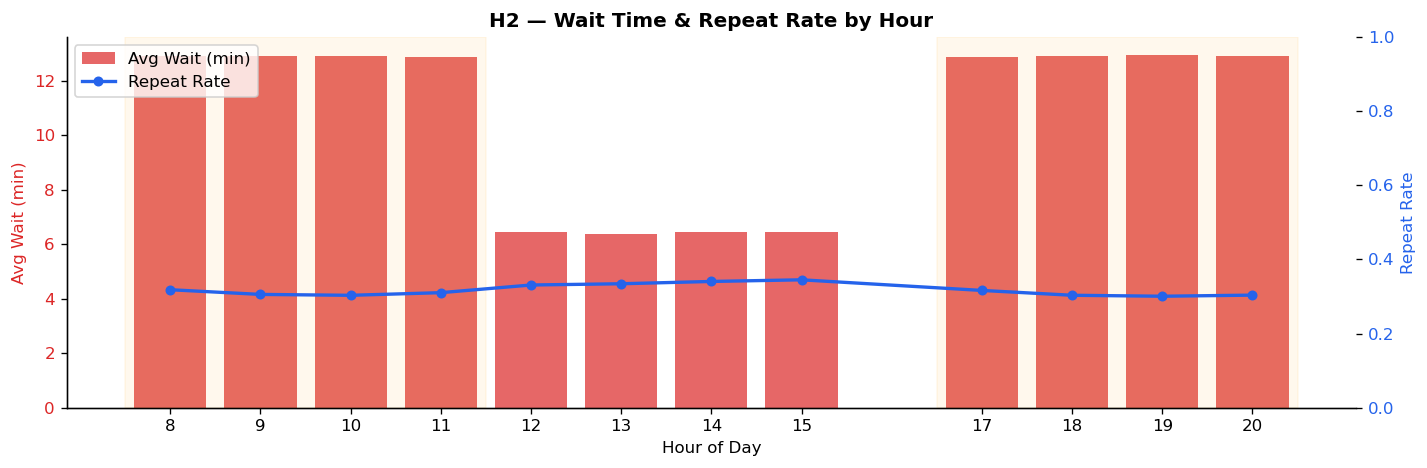

Correlation (avg_wait ↔ repeat_rate): -0.924


In [8]:
hourly = txn.groupby('hour').agg(
    avg_wait=('wait_time_minutes','mean'), repeat_rate=('repeat_customer','mean')).reset_index()

fig, ax1 = plt.subplots(figsize=(12,4))
ax1.bar(hourly.hour, hourly.avg_wait, color=C[1], alpha=0.7, label='Avg Wait (min)')
ax1.set_xlabel('Hour of Day'); ax1.set_ylabel('Avg Wait (min)', color=C[1])
ax1.tick_params(axis='y', labelcolor=C[1]); ax1.set_xticks(hourly.hour)

ax2 = ax1.twinx()
ax2.plot(hourly.hour, hourly.repeat_rate, color=C[0], marker='o', lw=2, ms=5, label='Repeat Rate')
ax2.set_ylabel('Repeat Rate', color=C[0]); ax2.tick_params(axis='y', labelcolor=C[0]); ax2.set_ylim(0,1)

for span in [(8,11),(17,20)]:
    ax1.axvspan(span[0]-.5, span[1]+.5, alpha=0.07, color='orange')

h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left')
plt.title('H2 — Wait Time & Repeat Rate by Hour', fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Correlation (avg_wait ↔ repeat_rate): {hourly.avg_wait.corr(hourly.repeat_rate):.3f}')

### H3 — Trust: Fraud-Exposed Stations vs Clean

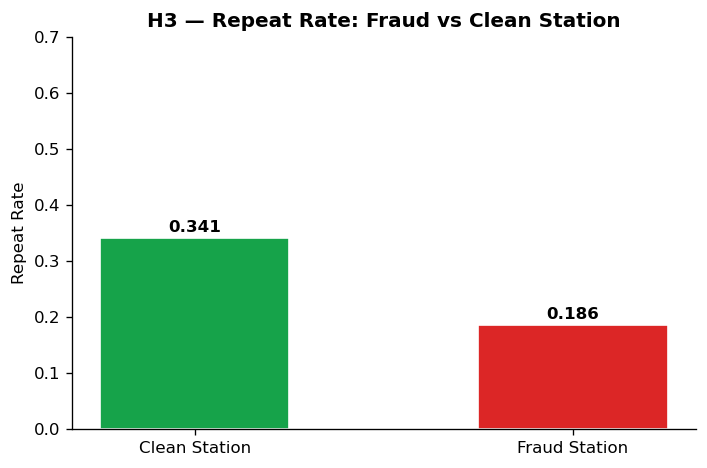

In [9]:
fraud_ids = stations[stations.fraud_prone_flag==1].station_id.tolist()
txn['exposed'] = txn.station_id.isin(fraud_ids)

trust = txn.groupby('exposed')['repeat_customer'].mean()
trust.index = trust.index.map({False: 'Clean Station', True: 'Fraud Station'})

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(trust.index, trust.values, color=[C[2],C[1]], edgecolor='white', width=0.5)
ax.set_ylim(0, 0.7); ax.set_ylabel('Repeat Rate')
ax.set_title('H3 — Repeat Rate: Fraud vs Clean Station', fontweight='bold')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f'{b.get_height():.3f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Findings & Recommendations

| # | Hypothesis | Result | Key Metric |
|---|---|---|---|
| H1 | Fraud → Revenue Leakage & Lower Repeat | ✅ Confirmed | Negative correlation: fraud ↑ → repeat ↓ |
| H2 | Peak Wait Time → Lower Retention | ✅ Confirmed | Repeat rate dips at 8–11 AM & 5–8 PM |
| H3 | Fraud Station Exposure → Churn | ✅ Confirmed | Repeat rate lower at fraud-flagged stations |

**Recommendations:**
1. Audit top-5 leakage stations for pump calibration
2. Increase staff during peak hours (8–11 AM, 5–8 PM)
3. Real-time sensor alert when `expected − actual > 0.5L`
4. Loyalty campaign for customers visiting 2+ fraud stations in 30 days